# 2-Site SFS
The two-site (or two-locus) SFS summarises pairs of linked sites: its entry $(i, j)$ counts pairs of sites, separated by up to `d` base pairs, at which one site carries $i$ and the other $j$ derived alleles. Its departure from the outer product of the one-dimensional spectrum reflects linkage and the shape of the underlying genealogies, which makes it a sensitive probe of departures from the standard (Kingman) coalescent, such as the multiple mergers produced by strong skew in reproductive success (see {cite:t}`fenton2025`).

Setting {attr}`~sfsutils.parser.Parser.two_sfs` to `TRUE` makes the {class}`~sfsutils.parser.Parser` pair sites within `d` base pairs and return a square {class}`~sfsutils.spectrum.TwoSFS`.

In [1]:
setwd("~/PycharmProjects/SFSUtils/")
reticulate::use_condaenv("/Users/janek/miniforge3/envs/sfsutils-dev", required = TRUE)


In [2]:
library(sfsutils)

su <- load_sfsutils()

In [3]:
options(repr.plot.width = 7.2, repr.plot.height = 5.3)

In [4]:
two_sfs <- su$Parser(
  source = "resources/msprime/two_sfs_kingman.all.vcf.gz",
  n = 10, two_sfs = TRUE, d = 1000
)$parse()[["all"]]

INFO:Parser: Using stratification: [all].
INFO:Parser: Loading VCF file
Parser>Counting sites: 600000it [00:00, 4832397.99it/s]
Parser>Processing sites: 100%|██████████| 600000/600000 [03:44<00:00, 2671.71it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 600000 out of 600000 sites in total from the input.
INFO:Parser: Counted 299700000 site pairs within 1000 bp.



The raw two-site SFS is the symmetric matrix of pair counts, shown here as a heatmap with the monomorphic rows and columns omitted.

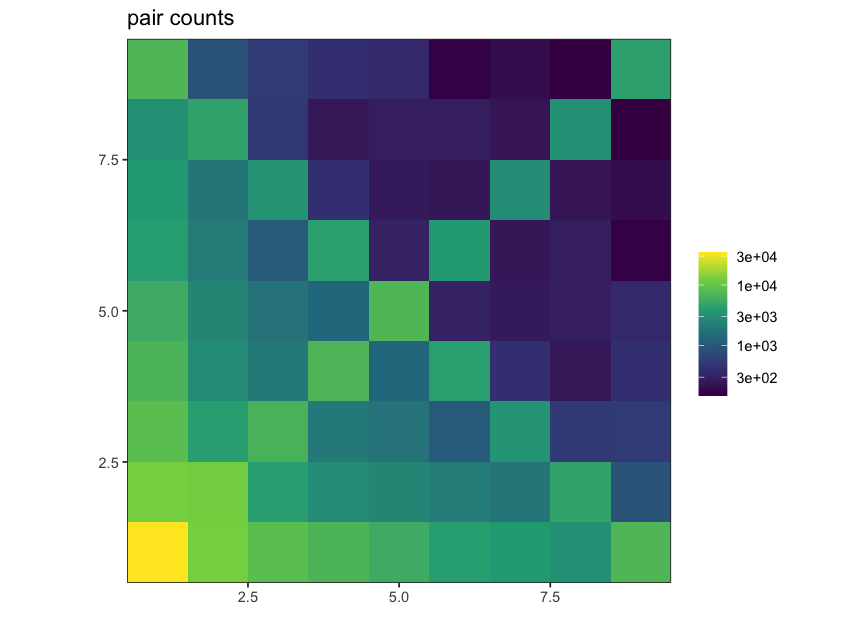

In [5]:
p <- two_sfs$plot(title = "pair counts")

Beyond the raw pair counts, {meth}`~sfsutils.spectrum.TwoSFS.cov` and {meth}`~sfsutils.spectrum.TwoSFS.corr` give the class-resolved branch-length covariance and correlation $\mathrm{Cov}(L_i, L_j)$ of the two linked sites, the deviation of the joint class distribution from independence. Because they normalise over the whole spectrum so that the marginal is the site-frequency spectrum, they require the monomorphic sites: parse an all-sites input.

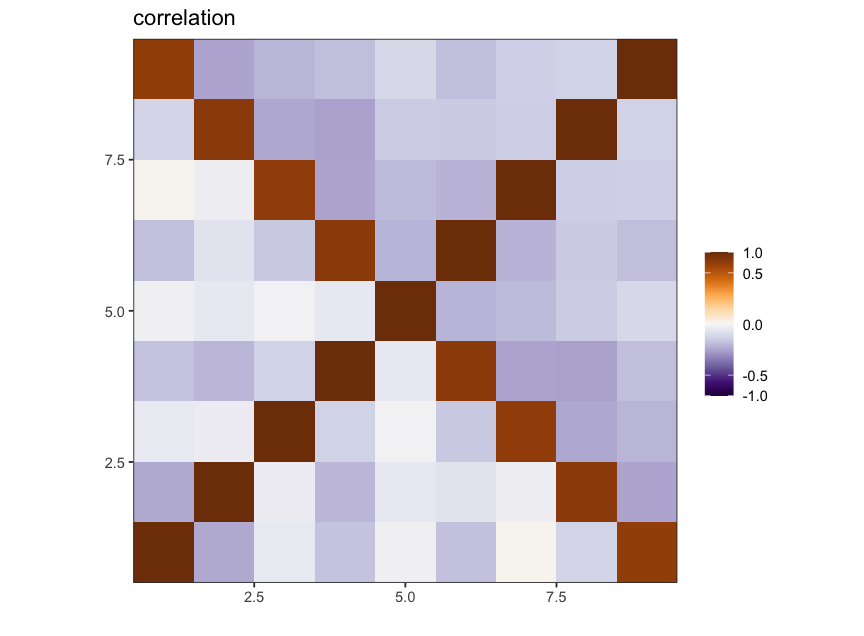

In [6]:
p <- two_sfs$corr()$plot(title = "correlation")

The spectrum can also be folded when the ancestral state is unknown, and the diagonals masked, as for any {class}`~sfsutils.spectrum.TwoSFS`.

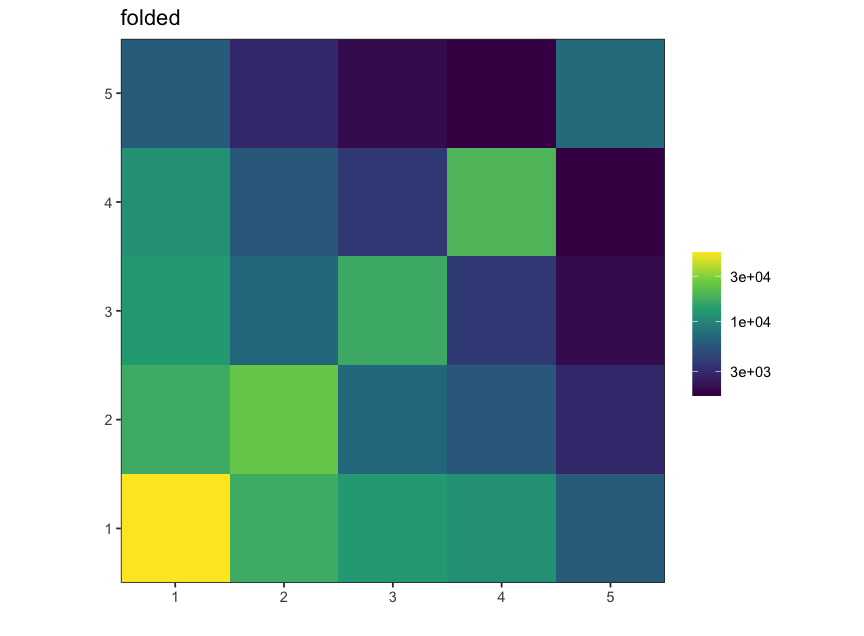

In [7]:
p <- two_sfs$fold()$plot(title = "folded")

## Detecting multiple mergers (MMCs)

Under the Kingman coalescent, mutations at different low frequencies are *negatively* correlated {cite:p}`fu1995`. Multiple-merger genealogies instead generate *positive* associations between low-frequency mutations {cite:p}`birkner2013`, the opposite sign. To see the contrast, we parse a second synthetic all-sites dataset, simulated under a Beta(1.3) multiple-merger coalescent, and compare its correlation with the Kingman one.

In [8]:
beta <- su$Parser(
  source = "resources/msprime/two_sfs_beta.all.vcf.gz",
  n = 10, two_sfs = TRUE, d = 1000
)$parse()[["all"]]

INFO:Parser: Using stratification: [all].
INFO:Parser: Loading VCF file
Parser>Counting sites: 600000it [00:00, 4810698.84it/s]
Parser>Processing sites: 100%|██████████| 600000/600000 [03:43<00:00, 2683.84it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 600000 out of 600000 sites in total from the input.
INFO:Parser: Counted 299700000 site pairs within 1000 bp.



In [9]:
options(repr.plot.width = 11.5, repr.plot.height = 4.8)

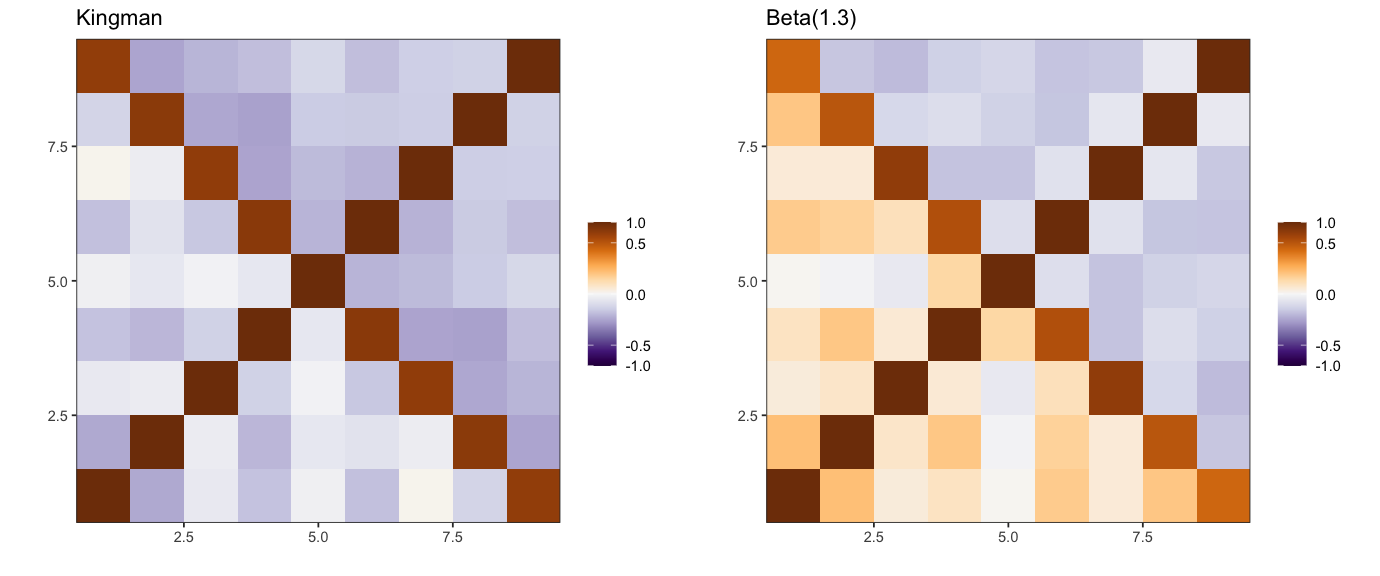

In [10]:
p_kingman <- two_sfs$corr()$plot(title = "Kingman", show = FALSE)
p_beta    <- beta$corr()$plot(title = "Beta(1.3)", show = FALSE)

cowplot::plot_grid(p_kingman, p_beta, ncol = 2)

The contrast in the low-frequency block, negative under Kingman and positive under the multiple-merger coalescent, is the signal that two-site spectra exploit to detect departures from Kingman coalescence.

Because {meth}`~sfsutils.spectrum.TwoSFS.cov` and {meth}`~sfsutils.spectrum.TwoSFS.corr` normalise over the full spectrum so that the marginal is the site-frequency spectrum, they require the real monomorphic sites of an all-sites input; a polymorphic-only (SNP) spectrum leaves them undefined and raises. The ratio statistic {meth}`~sfsutils.spectrum.TwoSFS.fpmi` needs no monomorphic sites and remains available for polymorphic-only data. The spectrum can also be folded when the ancestral state is unknown, and the diagonals masked, as for any {class}`~sfsutils.spectrum.TwoSFS`.